In [28]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [31]:
df = pd.read_csv('/content/netflix_titles (3).csv')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [32]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [34]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2518
cast             747
country          803
date_added         9
release_year       0
rating             4
duration           4
listed_in          1
description        1
dtype: int64


In [35]:
df = df.dropna()

In [36]:
df['release_year'] = pd.to_numeric(df['release_year'])

In [38]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [39]:
X = df[['release_year']]

In [40]:
y = df['duration_num']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
model = LinearRegression()

In [46]:
model.fit(X_train, y_train)

LinearRegression()

In [51]:
y_pred = model.predict(X_test)

In [52]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

MAE : 22.44850036539227


In [53]:
mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

MSE : 1034.3486728482155


In [54]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.058443856241193415


In [55]:
print("Coefficient :", model.coef_[0])

Coefficient : -0.770021030711312


In [56]:
print("Intercept :", model.intercept_)

Intercept : 1649.748718789946


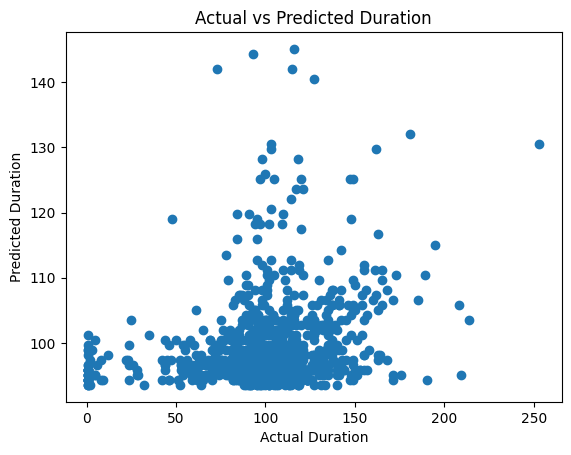

In [57]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")

plt.title("Actual vs Predicted Duration")
plt.show()

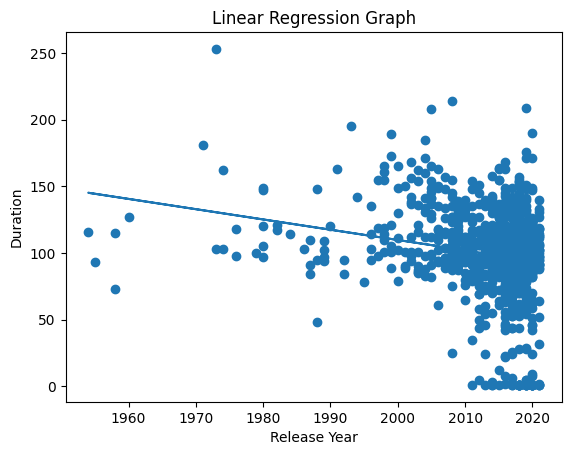

In [59]:
plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Release Year")
plt.ylabel("Duration")

plt.title("Linear Regression Graph")

plt.show()